        Simple Linear Reression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
%matplotlib inline
import seaborn as sns


In [3]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Weight')

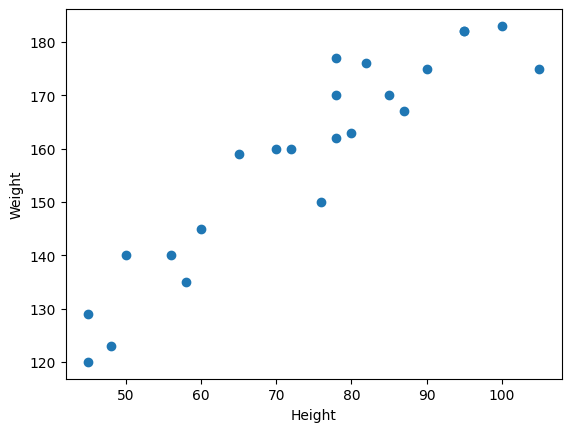

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Height")
plt.ylabel("Weight")


      Create independent and dependent features

In [5]:

x=df[['Weight']]
y=df['Height']

                  Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [7]:
x.shape,x_train.shape,x_test.shape

((23, 1), (18, 1), (5, 1))

      Standardization

IN Linear Regression Standardization needs to be apply

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

Fit compute the mean and dtandard deviation and trand=form apply the z score formula on every data point  


z=x-u/a

in test no fit because here no need of calculate standard deviation and mean again

transform() actually transforms the original data values into scaled values.


Test data par fit() nahi karte data leakage avoid karne ke liye.




         Data Leakage 
Definition

Data Leakage occurs when information from the test data or future information is accidentally used during the training of a machine learning model.


fit_transform(x_test) karne par test data ka mean & SD learn ho jata hai.

Isse test data ki information preprocessing mein use hoti hai → data leakage.

In [9]:
"""
fit(x_train)
    ↓
Train ka mean + SD learn
    ↓
transform(x_test)
    ↓
Test ko train ke rules se convert
    ↓
Clean evaluation ✅


fit_transform(x_test)
    ↓
Test ka mean + SD learn ❌
    ↓
Test ki information preprocessing mein aa gayi
    ↓
Data leakage / test contamination
"""

'\nfit(x_train)\n    ↓\nTrain ka mean + SD learn\n    ↓\ntransform(x_test)\n    ↓\nTest ko train ke rules se convert\n    ↓\nClean evaluation ✅\n\n\nfit_transform(x_test)\n    ↓\nTest ka mean + SD learn ❌\n    ↓\nTest ki information preprocessing mein aa gayi\n    ↓\nData leakage / test contamination\n'

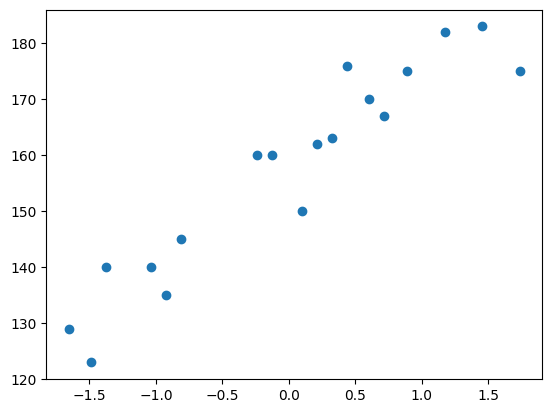

In [10]:
plt.scatter(x_train_scaled,y_train)

     Train Model

In [11]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print("the slope or coefficient of weight is:",model.coef_)
print("the intercept of height is:",model.intercept_)



the slope or coefficient of weight is: [17.03440872]
the intercept of height is: 157.5


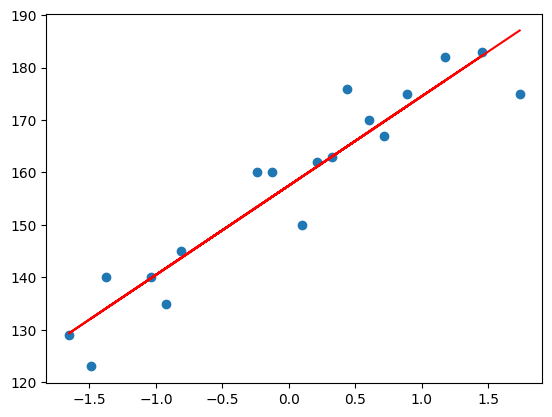

In [13]:
plt.scatter(x_train_scaled,y_train)
plt.plot(x_train_scaled,model.predict(x_train_scaled),color='red')

In [14]:
"""
Model ne equation learn ki
        ↓
x_train_scaled ki value equation me dali
        ↓
Predicted y value mili
        ↓
plt.plot() ne us X aur predicted Y ko plot/connect kar diya
"""

'\nModel ne equation learn ki\n        ↓\nx_train_scaled ki value equation me dali\n        ↓\nPredicted y value mili\n        ↓\nplt.plot() ne us X aur predicted Y ko plot/connect kar diya\n'

In [15]:
y_pred_test=model.predict(x_test_scaled)
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

In [19]:
from sklearn.metrics import mean_squared_error,mean_absolute_error  
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
print(mse)
print(mae)
rmse=np.sqrt(mse)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [20]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred_test)
print(score)

0.776986986042344


In [22]:
# display adjusted R-squared
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)

0.7026493147231252

   new data  point is 80.. how to predict for it

In [24]:
scaled_weight=scaler.transform([[80]])
scaled_weight

C:\Users\ad12c\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [27]:
model.predict([scaled_weight[0]])

array([163.01076266])

     Assumptions

plot scattter plot

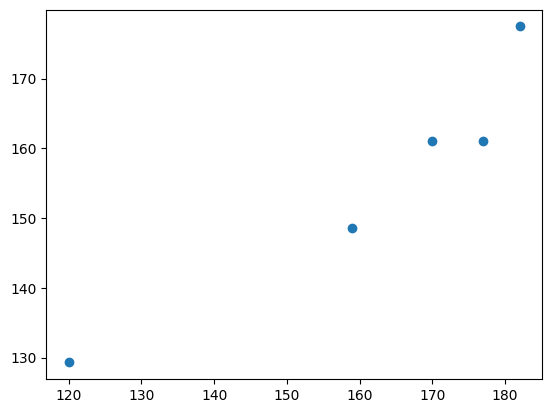

In [28]:
plt.scatter(y_test,y_pred_test  )

residuals

In [30]:
residuals=y_test-y_pred_test
residuals   

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\ad12c\AppData\Local\Temp\ipykernel_21424\3905197135.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

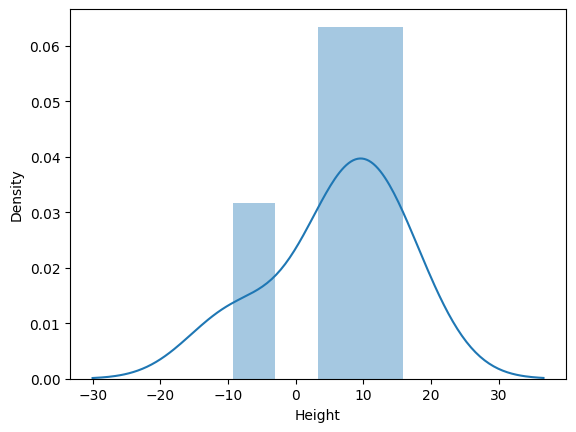

In [31]:
import seaborn as sns
sns.distplot(residuals,kde=True)